In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [2]:
class_count = {}
dataset_path = "../Rice Dataset/Augmented Dataset"
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        class_count[class_name] = len(os.listdir(class_path))
        print(f"Class: {class_name}, Count: {class_count[class_name]}") 

Class: Healthy, Count: 3995
Class: Insect, Count: 2084
Class: Leaf scald, Count: 2619
Class: rice, Count: 128
Class: Rice Blast, Count: 4450
Class: Rice Leaffolder, Count: 1658
Class: Rice Stripes, Count: 1818
Class: Rice Tungro, Count: 1784


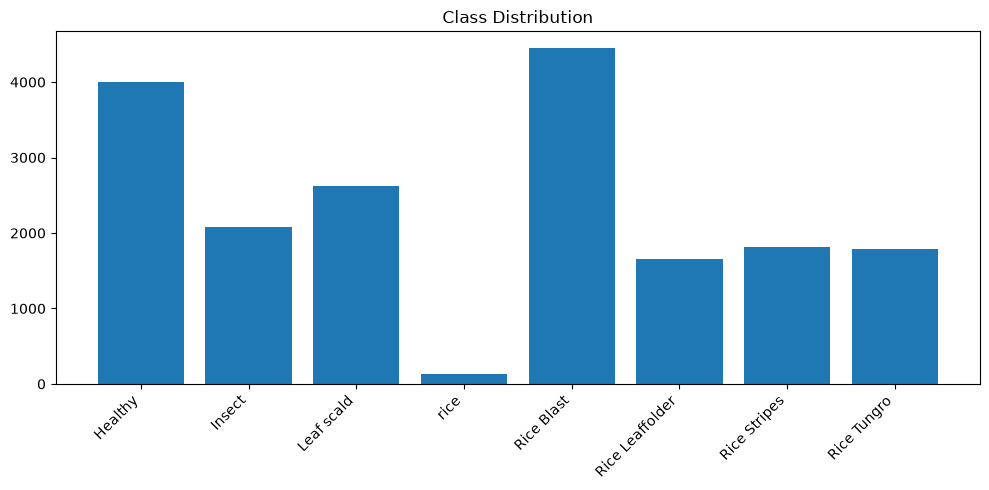

In [3]:
# Plot class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_count.keys(), class_count.values())
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution")
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

In [4]:
from torch.utils.data import Dataset
from PIL import Image

class RiceDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [5]:
print(os.listdir(dataset_path))

['Healthy', 'Insect', 'Leaf scald', 'rice', 'Rice Blast', 'Rice Leaffolder', 'Rice Stripes', 'Rice Tungro']


In [6]:
def build_file_list(dataset_path):
    image_paths = []
    labels = []
    
    class_names = sorted([
        d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))
                         ])
    
    print("Classes found:")
    for idx, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, class_name)
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        for img in images:
            image_paths.append(os.path.join(class_path, img))
            labels.append(idx)
        
        print(f"  {idx}: {class_name} — {len(images)} images")
        
    return image_paths, labels, class_names
        

In [7]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.RandomVerticalFlip(p=0.3),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    ])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
from sklearn.model_selection import train_test_split

def split_dataset(image_paths, labels):
    train_paths, temp_paths, train_labels, temp_labels = train_test_split(
        image_paths, labels, test_size=0.3, stratify=labels, random_state=42
    )
    
    val_paths, test_paths, val_labels, test_labels = train_test_split(temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42)
    
    return train_paths, val_paths, test_paths, train_labels, val_labels, test_labels

In [9]:
from torch.utils.data import DataLoader

def create_dataloaders(train_paths, val_paths, test_paths, train_labels, val_labels, test_labels, batch_size=32):
    train_dataset = RiceDataset(train_paths, train_labels, transform=train_transforms)
    val_dataset = RiceDataset(val_paths, val_labels, transform=val_transform)
    test_dataset = RiceDataset(test_paths, test_labels, transform=val_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    
    return train_loader, val_loader, test_loader

In [10]:
def verify_dataloader(loader, class_names):
    # Get one batch
    images, labels = next(iter(loader))
    
    print(f"Batch image shape: {images.shape}")
    # Should be: torch.Size([32, 3, 224, 224])
    # [batch_size, channels, height, width]
    
    print(f"Batch label shape: {labels.shape}")
    # Should be: torch.Size([32])
    
    print(f"Image value range: "
          f"{images.min():.3f} to {images.max():.3f}")
    # Should be roughly -2 to 2 after normalization
    
    print(f"Labels in batch: "
          f"{[class_names[l] for l in labels[:5]]}")
    # Should show class names, not just numbers
    

In [11]:
import torch
import torch.nn as nn
from torchvision import models

def get_model(num_classes, pretrained=True):
    # Load MobileNetV3 Small — edge friendly
    model = models.mobilenet_v3_small(
        weights='IMAGENET1K_V1' if pretrained else None
    )

    # Replace the classifier head
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)

    return model

In [12]:
import torch
from tqdm.notebook import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(tqdm(loader, desc="Training")):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc


In [13]:
def evaluate(model, loader, criterion, device, class_names):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating"):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(dim=1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    
    # Per class accuracy — important for imbalanced classes
    print("\nPer-class accuracy:")
    for class_idx, class_name in enumerate(class_names):
        class_mask = [l == class_idx for l in all_labels]
        class_preds = [
            all_predictions[i] for i, m 
            in enumerate(class_mask) if m
        ]
        class_true = [
            all_labels[i] for i, m 
            in enumerate(class_mask) if m
        ]
        if class_true:
            acc = sum(
                p == t for p, t 
                in zip(class_preds, class_true)
            ) / len(class_true)
            print(f"  {class_name}: {acc*100:.1f}%")
    
    return epoch_loss, epoch_acc

In [14]:
def train(config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    os.makedirs(config["output_dir"], exist_ok=True)
    
    image_paths, labels, class_names = build_file_list(
        config["dataset_path"]
    )
    
    split = split_dataset(image_paths, labels)
    loaders = create_dataloaders(*split, batch_size=config["batch_size"])
    train_loader, val_loader, test_loader = loaders
    
    verify_dataloader(train_loader, class_names)
    
    model = get_model(num_classes=len(class_names)).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    
    # Reduce LR when validation plateaus
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',      # maximize val accuracy
        patience=3,      # wait 3 epochs before reducing
        factor=0.5,      # halve the learning rate
    )
    
    # Training loop
    best_val_acc = 0.0
    history = []
    
    for epoch in range(config["epochs"]):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch+1}/{config['epochs']}")
        print(f"{'='*50}")
        
        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader,
            criterion, optimizer, device
        )
        
        # Evaluate
        val_loss, val_acc = evaluate(
            model, val_loader,
            criterion, device, class_names
        )
        
        # Update scheduler
        scheduler.step(val_acc)
        
        # Print summary
        print(f"\nTrain — Loss: {train_loss:.4f} "
              f"Acc: {train_acc:.2f}%")
        print(f"Val   — Loss: {val_loss:.4f} "
              f"Acc: {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'class_names': class_names
            }, os.path.join(
                config["output_dir"], "best_model.pt"
            ))
            print(f"✓ Best model saved ({val_acc:.2f}%)")
        
        # Log history
        history.append({
            "epoch": epoch + 1,
            "train_loss": round(train_loss, 4),
            "train_acc": round(train_acc, 2),
            "val_loss": round(val_loss, 4),
            "val_acc": round(val_acc, 2)
        })
    
    print(f"\nTraining complete")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    
    return history, model, class_names, test_loader
    

In [15]:
config = {
    "dataset_path": dataset_path,
    "output_dir": "./model_output",
    "batch_size": 32,
    "epochs": 30,
    "learning_rate": 1e-3
    }

history, model, class_names, test_loader = train(config)

Using device: cuda
Classes found:
  0: Healthy — 3995 images
  1: Insect — 2084 images
  2: Leaf scald — 2619 images
  3: Rice Blast — 4450 images
  4: Rice Leaffolder — 1658 images
  5: Rice Stripes — 1818 images
  6: Rice Tungro — 1784 images
  7: rice — 128 images
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Image value range: -2.118 to 2.640
Labels in batch: ['Rice Leaffolder', 'Rice Blast', 'Healthy', 'Rice Stripes', 'Rice Leaffolder']

Epoch 1/30


Training:   0%|          | 0/406 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/87 [00:00<?, ?it/s]


Per-class accuracy:
  Healthy: 78.8%
  Insect: 84.9%
  Leaf scald: 21.1%
  Rice Blast: 81.1%
  Rice Leaffolder: 62.2%
  Rice Stripes: 48.7%
  Rice Tungro: 18.7%
  rice: 84.2%

Train — Loss: 1.0441 Acc: 62.37%
Val   — Loss: 1.2339 Acc: 61.69%
✓ Best model saved (61.69%)

Epoch 2/30


Training:   0%|          | 0/406 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/87 [00:00<?, ?it/s]


Per-class accuracy:
  Healthy: 99.7%
  Insect: 95.8%
  Leaf scald: 98.5%
  Rice Blast: 97.0%
  Rice Leaffolder: 97.6%
  Rice Stripes: 93.8%
  Rice Tungro: 95.1%
  rice: 94.7%

Train — Loss: 0.0345 Acc: 98.87%
Val   — Loss: 0.1045 Acc: 97.19%
✓ Best model saved (97.19%)

Epoch 30/30


Training:   0%|          | 0/406 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/87 [00:00<?, ?it/s]


Per-class accuracy:
  Healthy: 99.2%
  Insect: 96.5%
  Leaf scald: 98.7%
  Rice Blast: 97.0%
  Rice Leaffolder: 98.8%
  Rice Stripes: 96.7%
  Rice Tungro: 95.9%
  rice: 94.7%

Train — Loss: 0.0276 Acc: 99.08%
Val   — Loss: 0.0921 Acc: 97.66%
✓ Best model saved (97.66%)

Training complete
Best validation accuracy: 97.66%


In [16]:
import torch
import torch.nn as nn
import torchvision
import os

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = torchvision.models.mobilenet_v3_small(weight=None)
model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, len(class_names))

# Load your saved weights
checkpoint = torch.load(
    "./model_output/best_model.pt",
    map_location='cpu'  # load to CPU for quantization
)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded successfully")

Using device: cuda
Model loaded successfully


In [18]:
import time
import numpy as np

def benchmark(model, runs=50):
    dummy = torch.randn(1, 3, 224, 224)
    times = []
    
    # Warmup
    for _ in range(10):
        with torch.no_grad():
            model(dummy)
    
    # Measure
    for _ in range(runs):
        start = time.perf_counter()
        with torch.no_grad():
            model(dummy)
        times.append(time.perf_counter() - start)
    
    avg_ms = np.mean(times) * 1000
    print(f"Avg inference: {avg_ms:.2f}ms ({1000/avg_ms:.1f} FPS)")
    return avg_ms

def model_size_mb(model):
    torch.save(model.state_dict(), "temp.pt")
    size = os.path.getsize("temp.pt") / 1e6
    os.remove("temp.pt")
    print(f"Model size: {size:.2f}MB")
    return size

print("=== Baseline ===")
baseline_time = benchmark(model)
baseline_size = model_size_mb(model)

=== Baseline ===
Avg inference: 2.47ms (404.3 FPS)
Model size: 6.22MB


In [19]:
# Dynamic quantization — simplest, do this first
quantized_model = torch.quantization.quantize_dynamic(
    model,
    {nn.Linear, nn.Conv2d},
    dtype=torch.qint8
)

print("=== Quantized ===")
quant_time = benchmark(quantized_model)
quant_size = model_size_mb(quantized_model)

# Print comparison
print(f"\n=== Comparison ===")
print(f"Size:  {baseline_size:.2f}MB → {quant_size:.2f}MB "
      f"({(1 - quant_size/baseline_size)*100:.1f}% reduction)")
print(f"Speed: {baseline_time:.2f}ms → {quant_time:.2f}ms "
      f"({(1 - quant_time/baseline_time)*100:.1f}% faster)")

=== Quantized ===


/tmp/ipykernel_5179/923733112.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


Avg inference: 2.53ms (395.1 FPS)
Model size: 4.43MB

=== Comparison ===
Size:  6.22MB → 4.43MB (28.8% reduction)
Speed: 2.47ms → 2.53ms (-2.3% faster)


In [20]:
def test_accuracy(model, loader, class_names):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Testing"):
            # Quantized model runs on CPU
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    
    overall_acc = 100. * correct / total
    print(f"\nOverall accuracy: {overall_acc:.2f}%")
    
    # Per class breakdown
    print("\nPer-class accuracy:")
    for idx, class_name in enumerate(class_names):
        mask = [l == idx for l in all_labels]
        class_preds = [all_preds[i] for i, m in enumerate(mask) if m]
        class_true = [all_labels[i] for i, m in enumerate(mask) if m]
        if class_true:
            acc = sum(
                p == t for p, t in zip(class_preds, class_true)
            ) / len(class_true)
            print(f"  {class_name}: {acc*100:.1f}%")
    
    return overall_acc

# Test both models
print("=== Baseline Accuracy ===")
baseline_acc = test_accuracy(model, test_loader, class_names)

print("\n=== Quantized Accuracy ===")
quant_acc = test_accuracy(quantized_model, test_loader, class_names)

print(f"\nAccuracy drop: {baseline_acc - quant_acc:.2f}%")

=== Baseline Accuracy ===


Testing:   0%|          | 0/87 [00:00<?, ?it/s]


Overall accuracy: 97.88%

Per-class accuracy:
  Healthy: 99.0%
  Insect: 97.1%
  Leaf scald: 98.0%
  Rice Blast: 97.9%
  Rice Leaffolder: 98.0%
  Rice Stripes: 96.7%
  Rice Tungro: 97.0%
  rice: 100.0%

=== Quantized Accuracy ===


Testing:   0%|          | 0/87 [00:00<?, ?it/s]


Overall accuracy: 97.81%

Per-class accuracy:
  Healthy: 99.0%
  Insect: 97.1%
  Leaf scald: 97.7%
  Rice Blast: 97.9%
  Rice Leaffolder: 98.0%
  Rice Stripes: 96.3%
  Rice Tungro: 97.0%
  rice: 100.0%

Accuracy drop: 0.07%


In [24]:
import onnx
import onnxruntime as ort

# Install if needed
# !pip install onnx onnxruntime

# Export baseline model to ONNX
dummy_input = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model,
    dummy_input,
    "rice_disease.onnx",
    export_params=True,
    opset_version=11,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    }
)

# Verify export
onnx_model = onnx.load("rice_disease.onnx")
onnx.checker.check_model(onnx_model)
print("ONNX export successful")

# Benchmark ONNX runtime
session = ort.InferenceSession("rice_disease.onnx")
input_name = session.get_inputs()[0].name

times = []
for _ in range(50):
    start = time.perf_counter()
    session.run(None, {input_name: dummy_input.numpy()})
    times.append(time.perf_counter() - start)

onnx_time = np.mean(times) * 1000
print(f"ONNX Runtime: {onnx_time:.2f}ms ({1000/onnx_time:.1f} FPS)")

/tmp/ipykernel_5179/2305462623.py:10: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0616 12:45:37.202000 5179 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/venv/main/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/workspace/myenv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/workspace/myenv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/workspace/myenv/lib/python3.12/site-packages/onnxscript/version_converter/__in

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX export successful
ONNX Runtime: 0.87ms (1146.6 FPS)


In [25]:
print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"{'':20} {'Size':>10} {'Speed':>10} {'Accuracy':>10}")
print("-"*50)
print(f"{'Baseline PyTorch':20} "
      f"{baseline_size:>9.2f}MB "
      f"{baseline_time:>9.2f}ms "
      f"{baseline_acc:>9.2f}%")
print(f"{'Quantized PyTorch':20} "
      f"{quant_size:>9.2f}MB "
      f"{quant_time:>9.2f}ms "
      f"{quant_acc:>9.2f}%")
print(f"{'ONNX Runtime':20} "
      f"{'N/A':>10} "
      f"{onnx_time:>9.2f}ms "
      f"{'N/A':>10}")
print("="*50)


FINAL RESULTS
                           Size      Speed   Accuracy
--------------------------------------------------
Baseline PyTorch          6.22MB      2.47ms     97.88%
Quantized PyTorch         4.43MB      2.53ms     97.81%
ONNX Runtime                N/A      0.87ms        N/A
